In [14]:
import torch
import nibabel as nib
import numpy as np
import torch.nn.functional as F
import os

def load_nii(file_path):
    """Loads a NIfTI image and normalizes it."""
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")

    img = nib.load(file_path).get_fdata()
    img = (img - np.mean(img)) / (np.std(img) + 1e-8)  # Standardization
    return img.astype(np.float32)

def preprocess_input(patient_folder):
    """Loads and preprocesses four MRI modalities from a given patient folder."""
    modalities = ["flair", "t1", "t1ce", "t2"]
    images = []

    for mod in modalities:
        file_path = os.path.join(patient_folder, f"BraTS20_Training_001_{mod}.nii")

        if not os.path.exists(file_path):
            raise FileNotFoundError(f"Missing modality: {mod}. Expected file: {file_path}")

        img_data = load_nii(file_path)
        images.append(img_data)

    images = np.stack(images, axis=0)  # Shape: (4, H, W, D)


    slice_idx = images.shape[-1] // 2
    image = images[:, :, :, slice_idx]  # Shape: (4, H, W)

    # Convert to tensor and resize to (224, 224)
    image_tensor = torch.tensor(image, dtype=torch.float32)
    image_tensor = F.interpolate(image_tensor.unsqueeze(0), size=(224, 224), mode="bilinear", align_corners=False).squeeze(0)

    return image_tensor.unsqueeze(0)  # Add batch dimension → (1, 4, 224, 224)


patient_folder = r"C:\Users\Dell\Desktop\Group_4_sem_6_AIML\image testing\BraTS20_Training_001"
try:
    input_tensor = preprocess_input(patient_folder)
    print("Final Input Shape:", input_tensor.shape)  # Should be (1, 4, 224, 224)
except FileNotFoundError as e:
    print(e)

Final Input Shape: torch.Size([1, 4, 224, 224])


In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from timm.models.swin_transformer import swin_tiny_patch4_window7_224 as SwinTransformer


class MultiScaleAttentionFusion(nn.Module):
    def __init__(self, in_channels):
        super(MultiScaleAttentionFusion, self).__init__()

        self.channel_attn = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_channels, in_channels // 4, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels // 4, in_channels, 1, bias=False),
            nn.Sigmoid()
        )

        self.spatial_attn = nn.Sequential(
            nn.Conv2d(in_channels, 1, kernel_size=7, padding=3, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        c_attn = self.channel_attn(x)
        x = x * c_attn
        s_attn = self.spatial_attn(x)
        x = x * s_attn
        return x


class UpBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super(UpBlock, self).__init__()
        self.upsample = nn.Sequential(
            nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2),
        )
        self.conv = nn.Sequential(
            nn.Conv2d(out_channels + skip_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x, skip):
        x = self.upsample(x)
        x = torch.cat([x, skip], dim=1)
        return self.conv(x)


class SwinUNet(nn.Module):
    def __init__(self, img_size=224, in_channels=4, out_channels=4):
        super(SwinUNet, self).__init__()

        self.swin = SwinTransformer(pretrained=True)
        self.swin.head = nn.Identity()
        self.swin.patch_embed.proj = nn.Conv2d(in_channels, 96, kernel_size=4, stride=4, padding=0)

        self.attn1 = MultiScaleAttentionFusion(768)
        self.attn2 = MultiScaleAttentionFusion(384)
        self.attn3 = MultiScaleAttentionFusion(192)
        self.attn4 = MultiScaleAttentionFusion(96)

        self.up1 = UpBlock(768, 384, 384)
        self.up2 = UpBlock(384, 192, 192)
        self.up3 = UpBlock(192, 96, 96)
        self.up4 = nn.Sequential(
            nn.ConvTranspose2d(96, out_channels, kernel_size=2, stride=2)
        )

        # Deep supervision outputs
        self.aux_out1 = nn.Conv2d(384, out_channels, kernel_size=1)
        self.aux_out2 = nn.Conv2d(192, out_channels, kernel_size=1)

    def forward(self, x):
        B, C, H, W = x.shape

        x = self.swin.patch_embed(x)
        x = self.swin.patch_embed.norm(x)
        x = self.swin.layers[0](x)
        x1 = x.permute(0, 3, 1, 2)
        x = self.swin.layers[1](x)
        x2 = x.permute(0, 3, 1, 2)
        x = self.swin.layers[2](x)
        x3 = x.permute(0, 3, 1, 2)
        x = self.swin.layers[3](x)
        x4 = x.permute(0, 3, 1, 2)

        # Apply attention to skip features
        x1 = self.attn4(x1)
        x2 = self.attn3(x2)
        x3 = self.attn2(x3)
        x4 = self.attn1(x4)

        # Decoder with skip connections
        x = self.up1(x4, x3)
        aux1 = self.aux_out1(x)
        x = self.up2(x, x2)
        aux2 = self.aux_out2(x)
        x = self.up3(x, x1)
        x = self.up4(x)

        return x, aux1, aux2


# Loss Functions
class SoftDiceLoss(nn.Module):
    def __init__(self, smooth=1.):
        super(SoftDiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, pred, target):
        # Resize target if shape mismatch
        if pred.shape[2:] != target.shape[1:]:
            target = F.interpolate(target.unsqueeze(1).float(), size=pred.shape[2:], mode="nearest").squeeze(1).long()

        # Assert class values are within range
        assert target.max() < pred.shape[1], f"Target has class {target.max().item()} >= num_classes {pred.shape[1]}"

        pred = torch.softmax(pred, dim=1)
        target_one_hot = F.one_hot(target, num_classes=pred.shape[1]).permute(0, 3, 1, 2).float()

        dims = (0, 2, 3)
        intersection = (pred * target_one_hot).sum(dim=dims)
        union = pred.sum(dim=dims) + target_one_hot.sum(dim=dims)
        dice = (2. * intersection + self.smooth) / (union + self.smooth)
        return 1 - dice.mean()


import torch.nn.functional as F

def combined_loss(preds, target):
    main_pred, aux1, aux2 = preds

    # Resize target to match the main_pred size (112x112)
    target_resized = F.interpolate(target.unsqueeze(1).float(), size=main_pred.shape[2:], mode="nearest").squeeze(1).long()

    # Debugging: Ensure target values are within the expected range
    assert torch.min(target_resized) >= 0 and torch.max(target_resized) < 4, "Target values must be in the range [0, 3]"
    print(f"Resized target min/max: {torch.min(target_resized)} / {torch.max(target_resized)}")
    
    # Dice + CrossEntropy for main prediction
    dice_loss = SoftDiceLoss()(main_pred, target_resized)
    ce_loss = nn.CrossEntropyLoss(
        weight=torch.tensor([0.1, 1.0, 1.0, 3.0]).to(main_pred.device)
    )(main_pred, target_resized)

    # Resize target to match aux1 and aux2 sizes
    target_aux1 = F.interpolate(target.unsqueeze(1).float(), size=aux1.shape[2:], mode="nearest").squeeze(1).long()
    target_aux2 = F.interpolate(target.unsqueeze(1).float(), size=aux2.shape[2:], mode="nearest").squeeze(1).long()

    # Auxiliary losses
    aux1_loss = nn.CrossEntropyLoss()(aux1, target_aux1)
    aux2_loss = nn.CrossEntropyLoss()(aux2, target_aux2)

    # Total loss: Weighted sum
    total_loss = dice_loss + ce_loss + 0.5 * aux1_loss + 0.5 * aux2_loss
    return total_loss



# Test
if __name__ == "__main__":
    device = "cpu"
    model = SwinUNet().to(device)
    dummy_input = torch.randn(2, 4, 224, 224).to(device)
    outputs = model(dummy_input)
    print("✅ Refactored Swin-UNet Forward Pass Successful! Output shape:", outputs[0].shape)

✅ Refactored Swin-UNet Forward Pass Successful! Output shape: torch.Size([2, 4, 112, 112])


In [16]:
import torch
from torch.serialization import add_safe_globals
from timm.models.swin_transformer import SwinTransformer
from timm.layers.patch_embed import PatchEmbed

In [17]:
add_safe_globals([
    SwinUNet, SwinTransformer, PatchEmbed,

    # Common PyTorch modules
    nn.Conv2d, nn.BatchNorm2d, nn.ReLU, nn.Sequential, nn.Upsample, nn.AdaptiveAvgPool2d,
    nn.Sigmoid, nn.Identity, nn.Module
])

In [18]:
model = SwinUNet().to(device)
model.load_state_dict(torch.load(r"C:\Users\Dell\Desktop\Group_4_sem_6_AIML\saved model\2019_combined_loss_finetuned_lgg.pth"))
print("✅ Final Model loaded successfully")

✅ Final Model loaded successfully


In [19]:
# Assuming your model is on the GPU (device = torch.device('cuda') or 'cpu')
device = torch.device("cpu")

# Move the model to the correct device
model = model.to(device)

# Make sure the input tensor is also on the same device
input_tensor = input_tensor.to(device)

# Now, you can pass the input tensor through the model
output = model(input_tensor)

In [20]:


# If output is a tuple, select the first element (usually the prediction)
if isinstance(output, tuple):
    output = output[0]

# Convert to binary mask (threshold = 0.5)
output_mask = (torch.sigmoid(output) > 0.5).float().cpu().numpy().squeeze()

print("✅ Inference complete! Mask shape:", output_mask.shape)

✅ Inference complete! Mask shape: (4, 112, 112)


In [21]:
import torch
import torch.nn.functional as F

# Remove extra dimension by squeezing
output = output.squeeze()  # Remove dimensions with size 1

# Ensure the output has the expected dimensions:
if len(output.shape) == 3:
    output = output.unsqueeze(1)
elif len(output.shape) == 5:
    output = output.squeeze(0).squeeze(0)
    output = output.unsqueeze(1)

output_resized = F.interpolate(output, size=(224, 224), mode="nearest")

# Remove the extra channel dimension (N, 224, 224)
output_resized = output_resized.squeeze(1)

print("✅ Resized Mask Shape:", output_resized.shape) # Expected: (4, 224, 224)

✅ Resized Mask Shape: torch.Size([4, 224, 224])


Output shape: (4, 224, 224)


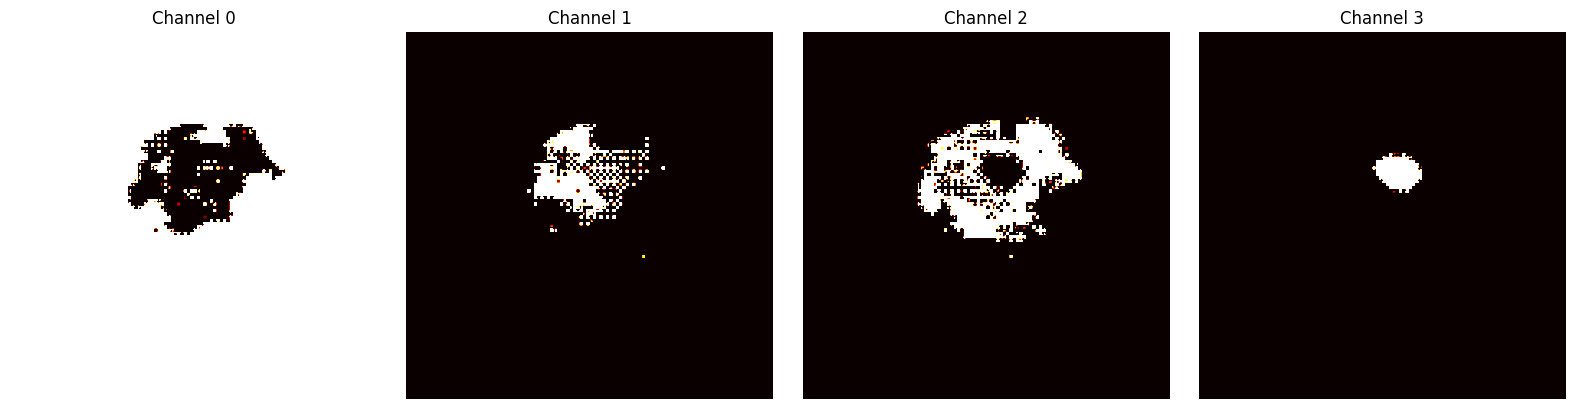

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Ensure values are in [0, 1] range for visualization
output_np = output_resized.cpu().detach().numpy()
output_np = np.clip(output_np, 0, 1)  # Ensure no weird values

print(f"Output shape: {output_np.shape}")

# Create a figure with 4 subplots
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Since your data has shape (4, 224, 224) or (1, 4, 224, 224)
for i in range(4):
    # Get the correct image based on shape
    if len(output_np.shape) == 4:  # Shape (1, 4, 224, 224)
        img = output_np[0, i]
    else:  # Shape (4, 224, 224)
        img = output_np[i]
    
    # Enhance visibility of the mask
    # Method 1: Normalize the mask to use full intensity range
    mask_normalized = (img - np.min(img)) / (np.max(img) - np.min(img) + 1e-8)
    
    # Method 2: Apply thresholding to make binary mask more visible
    # binary_mask = (img > 0.05).astype(float)  # Uncomment if needed
    
    # Apply sharpening filter
    kernel = np.array([[-1,-1,-1], [-1,9,-1], [-1,-1,-1]])
    filtered = cv2.filter2D(mask_normalized, -1, kernel)
    
    # Display the enhanced mask
    axes[i].imshow(filtered, cmap="hot", vmin=0, vmax=1)  # Try "hot" colormap for better visibility
    axes[i].axis("off")
    axes[i].set_title(f"Channel {i}")

plt.tight_layout()
plt.show()

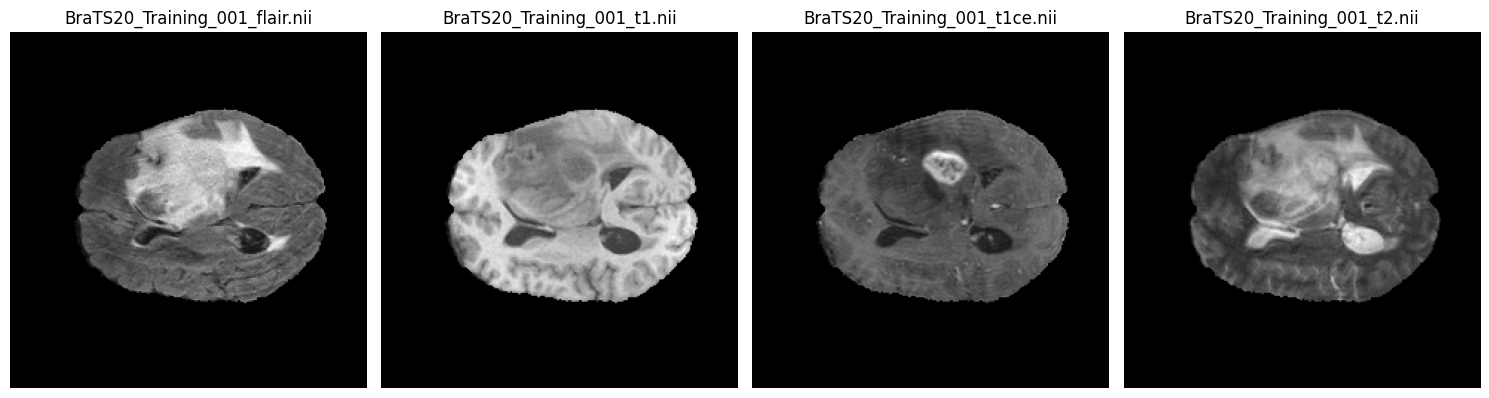

In [23]:
import os
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Define the patient folder path (you'll need to set this)
patient_folder = r"C:\Users\Dell\Desktop\Group_4_sem_6_AIML\image testing\BraTS20_Training_001"

nii_files = [f for f in os.listdir(patient_folder) if f.endswith((".nii", ".nii.gz"))]

# Function to load and display a single slice from a NIfTI file
def load_nii_slice(nii_path, slice_idx=None):
    nii_img = nib.load(nii_path)  # Load NIfTI file
    img_data = nii_img.get_fdata()  # Convert to NumPy array (3D)

    if slice_idx is None:
        slice_idx = img_data.shape[2] // 2  # Default to middle slice

    slice_2d = img_data[:, :, slice_idx]

    # Normalize image to [0, 255] for proper visualization
    slice_2d = (slice_2d - np.min(slice_2d)) / (np.max(slice_2d) - np.min(slice_2d))
    slice_2d = (slice_2d * 255).astype(np.uint8)

    return slice_2d

# Plot NIfTI images
if nii_files:
    fig, axes = plt.subplots(1, len(nii_files), figsize=(15, 5))
    
    # Handle case where there's only one file (axes won't be an array)
    if len(nii_files) == 1:
        axes = [axes]
    
    for i, nii_file in enumerate(nii_files):
        nii_path = os.path.join(patient_folder, nii_file)
        img = load_nii_slice(nii_path)

        axes[i].imshow(img, cmap="gray")
        axes[i].set_title(nii_file)
        axes[i].axis("off")
    
    plt.tight_layout()
    plt.show()

# For the second part - processing output_resized tensor
def visualize_tensor_output(output_tensor):
    # Ensure values are in [0, 1] range for visualization
    output_np = output_tensor.cpu().detach().numpy()
    output_np = np.clip(output_np, 0, 1)
    
    print(f"Output tensor shape: {output_np.shape}")
    
    # Create figure for visualization
    fig, axes = plt.subplots(1, 4, figsize=(12, 4))
    
    # Handle tensor based on its shape
    if len(output_np.shape) == 4 and output_np.shape[0] == 1:  # Shape: (1, 4, H, W)
        for i in range(4):
            # Extract image from batch 0, channel i
            img = output_np[0, i]
            
            # Apply sharpening filter
            kernel = np.array([[-1,-1,-1], [-1,9,-1], [-1,-1,-1]])
            filtered = cv2.filter2D(img, -1, kernel)
            
            # Display the filtered image
            axes[i].imshow(filtered, cmap="gray", vmin=0, vmax=1)
            axes[i].set_title(f"Channel {i}")
            axes[i].axis("off")
    else:
        print(f"Warning: Unexpected tensor shape: {output_np.shape}")
        # Try to handle other common shapes
        if len(output_np.shape) == 3:  # Shape: (C, H, W)
            for i in range(min(4, output_np.shape[0])):
                img = output_np[i]
                kernel = np.array([[-1,-1,-1], [-1,9,-1], [-1,-1,-1]])
                filtered = cv2.filter2D(img, -1, kernel)
                axes[i].imshow(filtered, cmap="gray", vmin=0, vmax=1)
                axes[i].set_title(f"Channel {i}")
                axes[i].axis("off")
    
    plt.tight_layout()
    plt.show()

# Example usage:
# visualize_tensor_output(output_resized)

Output shape: (4, 224, 224)


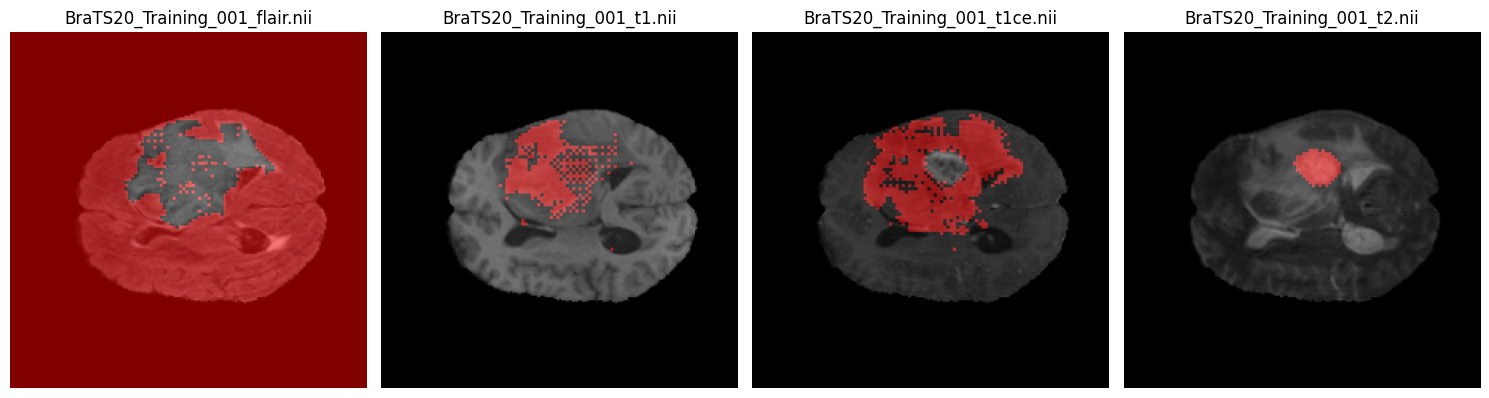

In [24]:
import os
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import cv2

nii_files = [f for f in os.listdir(patient_folder) if f.endswith((".nii"))]

# Assuming output_resized contains the masks
output_np = output_resized.cpu().detach().numpy()
output_np = np.clip(output_np, 0, 1)

# Print the shape to understand its structure
print(f"Output shape: {output_np.shape}")

def overlay_mask_on_image(image, mask, alpha=0.5, color=(1, 0, 0)):
    """Overlays a mask on an image with the specified color and transparency."""
    # Normalize image to 0-1
    image = (image - np.min(image)) / (np.max(image) - np.min(image))
    # Convert to uint8 (0-255)
    image = (image * 255).astype(np.uint8)

    # Convert grayscale image to RGB if needed
    if len(image.shape) == 2:
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
    
    # Create a colored mask with the same shape as the RGB image
    colored_mask = np.zeros_like(image)
    
    # Create a boolean mask
    binary_mask = mask > 0
    
    # Apply color to each channel where mask is True
    colored_mask[:,:,0] = np.where(binary_mask, int(color[0] * 255), 0)
    colored_mask[:,:,1] = np.where(binary_mask, int(color[1] * 255), 0)
    colored_mask[:,:,2] = np.where(binary_mask, int(color[2] * 255), 0)
    
    # Overlay the colored mask on the image
    overlayed_image = cv2.addWeighted(image, 1 - alpha, colored_mask, alpha, 0)
    
    return overlayed_image

# Create the figure
fig, axes = plt.subplots(1, len(nii_files), figsize=(15, 5))

# Handle the case where there's only one NIfTI file
if len(nii_files) == 1:
    axes = [axes]

# Handle the tensor properly based on its shape
for i, nii_file in enumerate(nii_files):
    nii_path = os.path.join(patient_folder, nii_file)
    
    # Load the image first to get its shape
    image_data = nib.load(nii_path).get_fdata()
    image = image_data[:, :, image_data.shape[2] // 2]
    
    # Resize image to match mask dimensions
    image_resized = cv2.resize(image, (output_np.shape[-1], output_np.shape[-2]))
    
    # Get the appropriate mask based on tensor shape
    if len(output_np.shape) == 4 and output_np.shape[0] == 1:  # (1, 4, H, W)
        mask = output_np[0, i]
    elif len(output_np.shape) == 3:  # (4, H, W)
        mask = output_np[i]
    else:
        raise ValueError(f"Unsupported output shape: {output_np.shape}")
    
    # Overlay mask on image
    overlayed_image = overlay_mask_on_image(image_resized, mask)
    
    # Display the overlaid image
    axes[i].imshow(overlayed_image)
    axes[i].set_title(nii_file)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

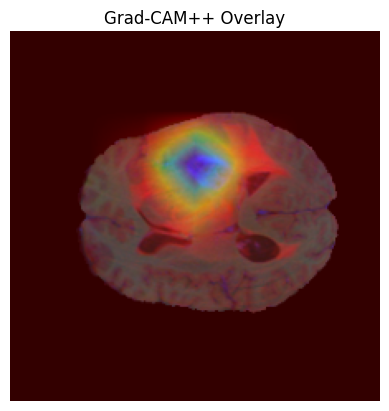

In [25]:
import torch
import torch.nn.functional as F
import numpy as np
import cv2
from torchvision import transforms
import matplotlib.pyplot as plt

class GradCAMPlusPlus:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.hook_handles = []
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        self.hook_handles.append(self.target_layer.register_forward_hook(forward_hook))
        self.hook_handles.append(self.target_layer.register_full_backward_hook(backward_hook))


    def remove_hooks(self):
        for handle in self.hook_handles:
            handle.remove()

    def __call__(self, input_tensor, class_idx=None):
        self.model.zero_grad()
        output, _, _ = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.mean(dim=(0, 2, 3)).argmax().item()

        target = output[:, class_idx].mean()
        target.backward(retain_graph=True)

        grads = self.gradients
        acts = self.activations

        alpha_num = grads.pow(2)
        alpha_denom = 2 * grads.pow(2) + acts * grads.pow(3)
        alpha_denom = torch.where(alpha_denom != 0.0, alpha_denom, torch.ones_like(alpha_denom))
        alpha = alpha_num / alpha_denom
        weights = (alpha * F.relu(grads)).sum(dim=(2, 3), keepdim=True)

        cam = (weights * acts).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        cam = F.interpolate(cam, size=input_tensor.shape[2:], mode='bilinear', align_corners=False)
        return cam.squeeze().cpu().numpy()

def overlay_heatmap_on_image(image_tensor, cam_map, alpha=0.5):
    # Convert 4-channel input to RGB for display (select first 3 channels)
    img_np = image_tensor.cpu().numpy()[0][:3]  # shape: [3, H, W]
    img_np = np.transpose(img_np, (1, 2, 0))  # HWC
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())
    img_np = (img_np * 255).astype(np.uint8)

    # Resize cam map
    cam_map = cv2.resize(cam_map, (img_np.shape[1], img_np.shape[0]), interpolation=cv2.INTER_CUBIC)
    cam_map = np.uint8(255 * cam_map)
    heatmap = cv2.applyColorMap(cam_map, cv2.COLORMAP_JET)

    overlayed = cv2.addWeighted(img_np, 1 - alpha, heatmap, alpha, 0)
    return overlayed

# === Inference + GradCAM++ Usage ===
# Preprocess your 4-channel input (assuming NCHW format)
input_tensor = preprocess_input(patient_folder).to(device)

# Ensure you're using the correct target layer (2nd conv in up1)
target_layer = model.attn1

grad_cam_pp = GradCAMPlusPlus(model, target_layer)
cam_map = grad_cam_pp(input_tensor)

overlay = overlay_heatmap_on_image(input_tensor, cam_map, alpha=0.4)

plt.imshow(overlay)
plt.axis('off')
plt.title("Grad-CAM++ Overlay")
plt.show()